# PRJ_06_02 LangGraph Legal PDF QA - LLM Agent

생성된 Chroma DB를 사용해 Adaptive RAG, Corrective RAG, Subgraph, Self-check 흐름을 실행하는 수업용 노트북입니다.


## 1. 환경 설정과 라이브러리


In [1]:
from __future__ import annotations
import argparse
import json
import os

import uuid

from operator import add
from pathlib import Path
from textwrap import dedent
from IPython.display import Image, display
from typing import Annotated, Callable, Literal, Optional, TypedDict

from dotenv import load_dotenv

from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_chroma import Chroma
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.retrievers import TavilySearchAPIRetriever
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain_ollama import OllamaEmbeddings
from langchain_openai import ChatOpenAI

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt.chat_agent_executor import create_react_agent

from pydantic import BaseModel, Field

import warnings
warnings.filterwarnings("ignore")

C:\Users\Admin\AppData\Local\Temp\ipykernel_20864\146066841.py:19: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.cross_encoders import HuggingFaceCrossEncoder


- env 정보 가져오기


In [2]:
load_dotenv()

True

- 디렉토리 정보


In [3]:
BASE_DIR = Path.cwd()

# Chroma Vector DB 저장 폴더
CHROMA_DIR = BASE_DIR / "chroma_db"

print("BASE_DIR   :", BASE_DIR)
print("CHROMA_DIR :", CHROMA_DIR)

BASE_DIR   : c:\Users\Admin\Desktop\LangChain\02. Langchain_Langgraph
CHROMA_DIR : c:\Users\Admin\Desktop\LangChain\02. Langchain_Langgraph\chroma_db


## 3. 기본 LLM 설정


In [4]:
llm = ChatOpenAI(model="gpt-4o", temperature=0.7)

## 4. Reranker 생성 함수
- RAG 검색 결과를 다시 평가해서, 질문과 더 관련성이 높은 문서만 상위 2개로 압축하기 위한 함수
- HuggingFaceCrossEncoder가 내부적으로 sentence-transformers 패키지를 필요로 함
- pip install -U sentence-transformers 설치 필요


In [5]:
def build_reranker() -> Optional[CrossEncoderReranker]:
    """ CrossEncoder 기반 Reranker를 생성하는 함수
        정상 생성 → CrossEncoderReranker 반환
        생성 실패 → None 반환
    """
    try:
        # HuggingFace CrossEncoder 모델 로드
        model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")
                # 질문(Query)과 검색 문서(Document)를 함께 입력하여 두 내용의 관련성을 점수로 평가하는 Reranker 모델
        return CrossEncoderReranker(model=model, top_n=2)
                # 검색된 여러 문서를 관련성 순으로 재정렬한 후 가장 관련성이 높은 상위 2개 문서만 선택
                
    except Exception as exc:
        print(f"[경고] reranker를 사용할 수 없습니다. 일반 retriever로 진행합니다: {exc}")
        return None

## 5. Chroma Retriever 생성 함수


In [6]:
def build_retriever(collection_name: str):
    embeddings = OllamaEmbeddings(model='bge-m3')  # Ollama 임베딩 모델 생성

    # Chroma Collection 연결
    db = Chroma(
        embedding_function=embeddings,
        collection_name=collection_name,
        persist_directory=str(CHROMA_DIR),
    )

    # Chroma DB를 기본 Retriever로 변환
    base_retriever = db.as_retriever(search_kwargs={"k": 5})   # 5개 검색
    reranker = build_reranker()   # Reranker 생성

    # Reranker를 사용할 수 없는 경우 일반 Chroma Retriever만 반환
    if reranker is None:
        return base_retriever

    # Reranker가 정상적으로 생성된 경우 관련성 있는 문서 반환
    return ContextualCompressionRetriever(
        base_compressor=reranker,
        base_retriever=base_retriever,
    )

## 6. 법률별 Retriever 로딩

In [7]:
personal_retriever = build_retriever("personal_law")    # 개인정보 보호법 Collection에 연결
labor_retriever = build_retriever("labor_law")          # 근로기준법 
tax_retriever = build_retriever("tax_law")              # 소득세법
housing_retriever = build_retriever("housing_law")      # 주택임대차보호법

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

## 7. 법률 검색 도구


In [8]:
# 개인정보보호법 
@tool
def personal_law_search(query: str) -> list[Document]:
    """개인정보보호법 법률 조항을 검색합니다."""
    
    docs = personal_retriever.invoke(query)
    return docs or [Document(page_content="관련 정보를 찾을 수 없습니다.")]

In [9]:
# 근로기준법
@tool
def labor_law_search(query: str) -> list[Document]:
    """근로기준법 법률 조항을 검색합니다."""
    
    docs = labor_retriever.invoke(query)
    return docs or [Document(page_content="관련 정보를 찾을 수 없습니다.")]

In [10]:
# 소득세법
@tool
def tax_law_search(query: str) -> list[Document]:
    """소득세법 법률 조항을 검색합니다."""
    
    docs = tax_retriever.invoke(query)
    return docs or [Document(page_content="관련 정보를 찾을 수 없습니다.")]

In [11]:
# 주택입대차보호법
@tool
def housing_law_search(query: str) -> list[Document]:
    """주택임대차보호법 법률 조항을 검색합니다."""
    
    docs = housing_retriever.invoke(query)
    return docs or [Document(page_content="관련 정보를 찾을 수 없습니다.")]

## 10. 웹 검색 도구


In [12]:
@tool
def web_search(query: str) -> list[Document]:
    """DB에 없는 정보 또는 최신 정보를 웹에서 검색합니다."""

    # 키 존재여부 확인
    if not os.getenv("TAVILY_API_KEY"):
        return [Document(page_content="TAVILY_API_KEY가 없어 웹 검색을 사용할 수 없습니다.")]

    # 5개의 문서 검색
    docs = TavilySearchAPIRetriever(k=5).invoke(query)

    # 검색 결과를 새로운 Document 형태로 정리
    formatted_docs = [
        Document(
            page_content=f'<Document href="{doc.metadata.get("source", "")}"/>\n{doc.page_content}\n</Document>',
            metadata={"source": "web search", "url": doc.metadata.get("source", "")},
        )
        for doc in docs
    ]
    return formatted_docs or [Document(page_content="관련 정보를 찾을 수 없습니다.")]

## 11. 도구 목록


In [13]:
TOOLS = [personal_law_search, labor_law_search, tax_law_search, housing_law_search, web_search]

## 12. 구조화 출력 모델


In [14]:
class InformationStrip(BaseModel):
    """
    검색 문서에서 추출한 핵심 정보와 해당 정보의 품질 평가 결과를 저장하는 데이터 모델
    """
    content: str = Field(..., description="추출된 정보 내용")  # 추출된 핵심 정보의 실제 내용 저장
    source: str = Field(..., description="정보 출처")          # 해당 정보가 어디에서 나온 것인지 저장
    relevance_score: float = Field(..., ge=0, le=1, description="질문 관련성")    # 사용자 질문과 추출 정보가 얼마나 관련되어 있는지 평가(0.0 ~ 1.0 범위)
    faithfulness_score: float = Field(..., ge=0, le=1, description="근거 충실성") # 추출한 정보가 원본 문서의 근거에 얼마나 충실한지를 평가(0.0 ~ 1.0 범위)

In [15]:
#  InformationStrip을 여러 개 묶어서 저장하고, 검색 문서 전체가 현재 질문에 답변하기에 얼마나 적합한지 점수까지 함께 저장하는 Pydantic 모델
class ExtractedInformation(BaseModel):
    """
    검색된 문서에서 추출한 여러 정보 조각과 전체적인 답변 가능성 점수를 저장하는 데이터 모델
    """
    strips: list[InformationStrip] = Field(..., description="추출된 정보 조각")   # 검색 문서에서 추출한 핵심 정보 조각들의 리스트
    query_relevance: float = Field(..., ge=0, le=1, description="답변 가능성 점수") # 추출된 정보 전체를 종합했을 때 현재 사용자 질문에 답변할 수 있는 정도(0.0 ~ 1.0 범위)

In [16]:
# Corrective RAG에서 검색 결과가 부족할 때 LLM이 기존 질문을 검색에 더 적합한 질문으로 재작성한 결과를 구조화해서 저장하는 Pydantic 모델
class RefinedQuestion(BaseModel):
    """
    검색 성능을 높이기 위해 LLM이 재작성한 질문과 질문을 변경한 이유를 저장하는 데이터 모델
    """
    question_refined: str = Field(..., description="개선된 검색 질문")
    reason: str = Field(..., description="질문을 개선한 이유")

## 13. Corrective RAG 상태 정의
- 검색 결과가 질문에 적절한지 평가하고 문제가 있으면 검색을 보정한 뒤 다시 답변을 생성하는 방식
    - 일반 RAG: 질문 → 검색 → 답변
    - Corrective RAG: 질문 → 검색 → 평가 → 보정 → 답변

In [17]:
class CorrectiveRagState(TypedDict, total=False):
    """
    Corrective RAG의 각 노드가 공유하는 State 정의
    검색 → 정보 평가 → 질문 재작성 → 재검색 → 답변 생성 과정에서 필요한 데이터를 저장합니다.
    """
    question: str
    documents: list[Document]
    rewritten_query: str
    extracted_info: list["InformationStrip"]
    num_generations: int
    node_answer: str

## 14. 추출 정보 포맷팅


In [18]:
def format_strips(strips: list[InformationStrip]) -> str:
    """
    InformationStrip 리스트를 읽기 쉬운 하나의 문자열로 변환하는 함수
    """
    if not strips:
        return "추출된 정보가 없습니다."
    
    return "\n\n".join(
        f"내용: {strip.content}\n"   
        f"출처: {strip.source}\n"               
        f"관련성: {strip.relevance_score}\n"
        f"충실성: {strip.faithfulness_score}"
        for strip in strips
    )

## 15. 법률별 Corrective RAG Subgraph 생성 함수
- 하나의 법률용 Corrective RAG 그래프를 통째로 만들어주는 “그래프 생성 함수”
- law_name과 retriever_tool만 바꿔서 개인정보보호법, 근로기준법, 소득세법, 주택임대차보호법용 Corrective RAG를 각각 만들 수 있게 설계한 구조


In [19]:
def build_corrective_rag_agent( *, law_name: str, 
                               retriever_tool: Callable[[str], list[Document]],):
    """특정 법률에 대한 Corrective RAG 그래프를 생성하는 함수"""

    # 문서 검색 Node
    def retrieve_documents(state: CorrectiveRagState) -> CorrectiveRagState:
        print(f"---{law_name}: 문서 검색---")

        # 재작성된 질문이 있으면 그것을 사용 / 없으면 원래 사용자 질문 사용
        query = (state.get("rewritten_query") or state["question"]
    )

        docs = retriever_tool.invoke(query)  # 해당 법률의 Retriever Tool 실행
        return {"documents": docs}

    # 검색 문서에서 정보 추출 + 품질 평가 Node
    def extract_and_evaluate_information(state: CorrectiveRagState) -> CorrectiveRagState:
        print(f"---{law_name}: 정보 추출 및 평가---")

        # 검색된 법률 문서에서 질문과 관련된 정보를 추출하고 평가하도록 LLM에게 지시하는 Prompt
        extract_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    f"""당신은 {law_name} 전문가입니다.
주어진 문서에서 질문과 관련된 주요 사실과 정보를 추출하고 평가하세요.
관련성 점수와 충실성 점수는 0에서 1 사이로 평가하세요.""",
                ),
                ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}"),
            ]
        )
        extract_llm = llm.with_structured_output(ExtractedInformation)  # LLM에 평가 프롬프트 적용
        extracted_strips: list[InformationStrip] = []  # 품질 평가를 통과한 InformationStrip을 저장할 리스트

        # Retriever가 검색한 문서를 하나씩 평가
        for doc in state.get("documents", []):
            # 질문과 문서를 기반으로: 핵심 정보 추출, 질문 관련성 평가, 근거 충실성 평가, 전체 답변 가능성 평가 등 진행
            extracted = extract_llm.invoke(
                extract_prompt.format(
                    question=state["question"],
                    document_content=doc.page_content,
                )
            )

            # 문서 전체의 답변 가능성 평가
            if extracted.query_relevance < 0.8:
                continue
            extracted_strips.extend(
                strip
                for strip in extracted.strips

                # 문서에서 추출한 개별 정보 조각 중 품질 기준을 만족하는 정보만 선택
                if strip.relevance_score >= 0.7 and strip.faithfulness_score >= 0.7
            )

        return {
            "extracted_info": extracted_strips,  # 평가를 통과한 정보들을 State에 저장
            "num_generations": state.get("num_generations", 0) + 1,
        }

    # 검색 질문 재작성 Node
    def rewrite_query(state: CorrectiveRagState) -> CorrectiveRagState:
        """ 현재 검색 결과가 부족한 경우 => 검색에 더 적합한 질문으로 다시 작성 """
        print(f"---{law_name}: 쿼리 재작성---")

        rewrite_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    f"""당신은 {law_name} 검색 전문가입니다.
원래 질문과 추출된 정보를 바탕으로 더 좋은 검색 쿼리를 하나 작성하세요.""",
                ),
                ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}"),
            ]
        )
        rewrite_llm = llm.with_structured_output(RefinedQuestion)
        response = rewrite_llm.invoke(
            rewrite_prompt.format(
                question=state["question"],
                extracted_info=format_strips(state.get("extracted_info", [])),
            )
        )
        return {"rewritten_query": response.question_refined}

    # 최종 답변 생성 Node
    def generate_node_answer(state: CorrectiveRagState) -> CorrectiveRagState:
        print(f"---{law_name}: 답변 생성---")
        answer_prompt = ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    f"""당신은 {law_name} 전문가입니다.
주어진 질문과 추출된 정보만 근거로 답변하세요.
답변에는 관련 법률 조항이나 출처를 명확히 표시하세요.""",
                ),
                ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}"),
            ]
        )
        response = llm.invoke(
            answer_prompt.format(
                question=state["question"],
                extracted_info=format_strips(state.get("extracted_info", [])),
            )
        )
        return {"node_answer": response.content}

    # 계속 검색할지 결정하는 조건 함수
    def should_continue(state: CorrectiveRagState) -> Literal["continue", "finish"]:
        # 검색/평가 횟수가 2회 이상이면 종료
        if state.get("num_generations", 0) >= 2:  
            return "finish"

        # 평가를 통과한 정보가 하나 이상 있으면 충분한 근거를 확보했다고 판단
        if len(state.get("extracted_info", [])) >= 1:
            return "finish"
        return "continue"

    # Node 등록
    workflow = StateGraph(CorrectiveRagState)
    workflow.add_node("retrieve", retrieve_documents)   # 문서 검색 Node
    workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)  # 정보 추출 및 평가 Node
    workflow.add_node("rewrite_query", rewrite_query)  # Query Rewrite Node
    workflow.add_node("generate_answer", generate_node_answer)  # 최종 답변 생성 Node

    # 엣지 추가
    workflow.add_edge(START, "retrieve")
    workflow.add_edge("retrieve", "extract_and_evaluate")

    workflow.add_conditional_edges(
        "extract_and_evaluate",
        # 평가 결과에 따른 조건부 분기
        should_continue,
        {"continue": "rewrite_query", 
         "finish": "generate_answer"},
    )

    workflow.add_edge("rewrite_query", "retrieve") 
    workflow.add_edge("generate_answer", END)
    
    return workflow.compile()

## 16. 법률별 Subgraph Agent 생성
- build_corrective_rag_agent() 함수를 호출하여 개인정보보호법 전용 Corrective RAG 그래프를 생성

In [20]:
personal_law_agent = build_corrective_rag_agent(
    law_name="개인정보보호법",
    retriever_tool=personal_law_search,
)

labor_law_agent = build_corrective_rag_agent(
    law_name="근로기준법",
    retriever_tool=labor_law_search,
)

tax_law_agent = build_corrective_rag_agent(
    law_name="소득세법",
    retriever_tool=tax_law_search,
)

housing_law_agent = build_corrective_rag_agent(
    law_name="주택임대차보호법",
    retriever_tool=housing_law_search,
)

web_rag_agent = build_corrective_rag_agent(
    law_name="인터넷 검색",
    retriever_tool=web_search,
)

## 17. 메인 Research Agent 상태 정의


In [21]:
class ResearchAgentState(TypedDict, total=False):
    """
    여러 Sub Agent의 검색/답변 결과를 모아서 최종 답변을 만드는 Research Agent의 State 정의
    """
    question: str
    answers: Annotated[list[str], add]
    datasources: list[str]
    final_answer: str
    evaluation_report: dict
    retry_count: int
    user_decision: str

## 18. Adaptive RAG 라우팅 출력 모델


In [22]:
# LLM이 사용자 질문을 분석해서 어떤 검색 도구를 사용할지 선택하도록 출력 형식을 제한하는 코드
class ToolSelector(BaseModel):
    # 사용자 질문에 사용할 Tool을 선택
    tool: Literal[          
        "search_personal",
        "search_labor",
        "search_housing",
        "search_web",
        "llm_fallback",
    ] = Field(description="Select the best tool for the user question.")

In [23]:
# ToolSelector를 여러 개 담을 수 있도록 만든 상위 데이터 모델
class ToolSelectors(BaseModel):
    tools: list[ToolSelector] = Field(description="Select one or more tools.")

## 19. 질문 라우팅 프롬프트
- 사용자의 질문을 분석하여 어떤 Tool/Sub-Agent로 보낼지 결정하기 위한 라우팅 프롬프트

In [24]:
route_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            dedent(
                """
                You route user questions to the most appropriate tools.
                - 개인정보 보호법 조항 질문: search_personal
                - 근로기준법 조항 질문: search_labor
                - 주택임대차보호법 조항 질문: search_housing
                - 최신 정보 또는 DB에 없는 정보: search_web
                - 법률/최신정보/문서검색과 무관한 일반 대화: llm_fallback
                Choose every tool that is needed.
                """
            ),
        ),
        ("human", "{question}"),
    ]
)

## 20. 질문 라우터 체인


In [25]:
question_router = route_prompt | llm.with_structured_output(ToolSelectors)

## 21. 질문 분석 노드
- Research Agent가 사용자의 질문을 분석한 뒤, 어떤 검색 도구/Sub-Agent를 사용할지 결정하고 그 결과를 State의 datasources에 저장하는 라우팅 노드

In [26]:
def analyze_question(state: ResearchAgentState) -> ResearchAgentState:
    """
    사용자 질문을 분석하여 필요한 Tool을 선택하고, 선택된 Tool 이름을 datasources에 저장하는 노드
    """
    result = question_router.invoke({"question": state["question"]})
    datasources = [item.tool for item in result.tools]   # 선택된 Tool 이름만 리스트로 추출
    return {"datasources": datasources or ["llm_fallback"]}

## 22. 조건부 라우팅 함수
- analyze_question()이 선택한 datasources를 검사해서, 허용된 Tool만 남기고 실제 LangGraph의 다음 실행 경로를 반환하는 라우팅 함

In [27]:
def route_datasources(state: ResearchAgentState) -> list[str]:
    """
    analyze_question()에서 선택한 Tool들을 검사하고, 실제로 실행할 LangGraph 노드 이름들을 반환하는 함수
    """
    valid = {"search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"}
    selected = [source for source in state.get("datasources", []) if source in valid]
    return selected or ["llm_fallback"]

## 23. Subgraph 호출 노드


In [28]:
def personal_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """
    개인정보보호법 Corrective RAG Sub-Agent를 실행하고 생성된 답변을 상위 Research Agent의 answers에 전달하는 Node
    """
    answer = personal_law_agent.invoke({"question": state["question"]})
    return {"answers": [answer.get("node_answer", "")]}

In [29]:
def labor_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """
    근로기준법 Corrective RAG Sub-Agent를 실행하고, 생성된 답변을 Research Agent의 answers에 전달하는 Node
    """
    answer = labor_law_agent.invoke({"question": state["question"]})
    return {"answers": [answer.get("node_answer", "")]}

In [30]:
def tax_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """
    소득세법 Corrective RAG Sub-Agent를 실행하고, 생성된 답변을 Research Agent의 answers에 전달하는 Node
    """
    answer = tax_law_agent.invoke({"question": state["question"]})
    return {"answers": [answer.get("node_answer", "")]}

In [31]:
def housing_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """
    주택임대차보호법 Corrective RAG Sub-Agent를 실행하고,
    생성된 답변을 상위 Research Agent의 answers에 전달하는 Node
    """
    answer = housing_law_agent.invoke({"question": state["question"]})
    return {"answers": [answer.get("node_answer", "")]}

In [32]:
def web_rag_node(state: ResearchAgentState) -> ResearchAgentState:
    """
    Web RAG Sub-Agent를 실행하여 웹에서 필요한 정보를 검색하고,
    생성된 답변을 Research Agent의 answers에 전달하는 Node
    """
    answer = web_rag_agent.invoke({"question": state["question"]})
    return {"answers": [answer.get("node_answer", "")]}

## 24. 최종 RAG 답변 프롬프트


In [33]:
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You answer using only the given documents.
If the documents are insufficient, say "제공된 정보로는 충분한 답변을 할 수 없습니다."
Cite legal articles or web sources whenever possible.""",
        ),
        ("human", "[Documents]\n{documents}\n\n[Question]\n{question}"),
    ]
)

## 25. 최종 답변 생성 노드


In [34]:
def answer_final(state: ResearchAgentState) -> ResearchAgentState:
    """
    여러 Sub-Agent가 생성한 답변을 하나로 통합하고, 사용자의 원래 질문에 대한 최종 답변을 생성하는 Node
    """
    print("---최종 답변 생성---")
    documents_text = "\n\n".join(state.get("answers", []))
    chain = rag_prompt | llm | StrOutputParser()
    answer = chain.invoke({"documents": documents_text, "question": state["question"]})
    return {"final_answer": answer}

## 26. LLM Fallback 프롬프트


In [35]:
# 전문 법률 검색이나 웹 검색이 필요하지 않은 일반 질문을 LLM이 직접 답변하도록 하기 위한 Fallback 프롬프트
fallback_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant. Answer clearly and avoid unsupported claims."),
        ("human", "{question}"),
    ]
)

## 27. LLM Fallback 노드


In [36]:
def llm_fallback(state: ResearchAgentState) -> ResearchAgentState:
    """
    법률 DB 검색이나 웹 검색이 필요하지 않은 일반적인 질문을 LLM이 직접 처리하는 Node
    """
    print("---LLM Fallback 답변---")
    chain = fallback_prompt | llm | StrOutputParser()
    answer = chain.invoke({"question": state["question"]})
    return {"final_answer": answer}

## 28. Self-check 평가 프롬프트


In [37]:
evaluation_prompt = dedent(
    """
    당신은 RAG 답변 평가자입니다. 질문과 답변을 평가하고 JSON만 출력하세요.
    평가 기준은 정확성, 관련성, 완전성, 인용 정확성, 명확성, 객관성입니다.

    출력 형식:
    {
      "scores": {
        "accuracy": 0,
        "relevance": 0,
        "completeness": 0,
        "citation_accuracy": 0,
        "clarity": 0,
        "objectivity": 0
      },
      "total_score": 0,
      "brief_evaluation": "간단한 평가",
      "needs_revision": false
    }
    """
)

## 29. 답변 평가 ReAct Agent


In [38]:
answer_reviewer = create_react_agent(llm, tools=TOOLS, prompt=evaluation_prompt)

## 30. 답변 평가 노드


In [39]:
def evaluate_answer(state: ResearchAgentState) -> ResearchAgentState:
    """
    Research Agent가 생성한 최종 답변을 다시 검토하여 답변의 품질을 평가하는 Self-check Node
    """

    print("---Self-check 답변 평가---")  # 현재 실행 중인 Node 확인

    message = HumanMessage(
        content=f"[질문]\n{state['question']}\n\n[답변]\n{state['final_answer']}"
    )
    response = answer_reviewer.invoke({"messages": [message]})
    content = response["messages"][-1].content    # 결과는 json 형식
    
    try:
        report = json.loads(content)
    except json.JSONDecodeError:
        report = {
            "scores": {},
            "total_score": 0,
            "brief_evaluation": content,
            "needs_revision": True,
        }
    return {"evaluation_report": report}

## 31. 평가 이후 재시도 판단


In [40]:
def decide_after_evaluation(state: ResearchAgentState) -> Literal["finish", "retry"]:
    retry_count = state.get("retry_count", 0)
    report = state.get("evaluation_report", {})
    total_score = int(report.get("total_score", 0))
    needs_revision = bool(report.get("needs_revision", False))

    if retry_count >= 1:
        return "finish"
    if needs_revision or total_score < 45:
        return "retry"
    return "finish"

## 32. 재시도 카운트 증가


In [41]:
def increase_retry_count(state: ResearchAgentState) -> ResearchAgentState:
    return {"retry_count": state.get("retry_count", 0) + 1, "answers": []}

## 33. 메인 LangGraph Agent 생성


In [42]:
def build_legal_rag_agent(with_hitl: bool = False):
    """
    여러 법률 Sub-Agent와 Web RAG, LLM Fallback, Self-check 평가를 연결한
    최종 Legal Research Agent를 생성하는 함수

    with_hitl=True → Checkpointer를 사용하여 상태 저장 기능 활성화
    """
    # Graph 노드 생성
    builder = StateGraph(ResearchAgentState)
    builder.add_node("analyze_question", analyze_question)
    builder.add_node("search_personal", personal_rag_node)
    builder.add_node("search_labor", labor_rag_node)
    builder.add_node("search_tax", tax_rag_node)
    builder.add_node("search_housing", housing_rag_node)
    builder.add_node("search_web", web_rag_node)
    builder.add_node("llm_fallback", llm_fallback)
    builder.add_node("generate_answer", answer_final)
    builder.add_node("evaluate_answer", evaluate_answer)
    builder.add_node("increase_retry_count", increase_retry_count)

    # 엣지 추가 및 분기 엣지 추가
    builder.add_edge(START, "analyze_question")
    builder.add_conditional_edges(
        "analyze_question",
        route_datasources,
        ["search_personal", "search_labor", "search_tax", "search_housing", "search_web", "llm_fallback"],
    )

    # 전문 검색 Node들의 결과를 최종 답변 생성 Node로 연결
    for node in ["search_personal", "search_labor", "search_tax", "search_housing", "search_web"]:
        builder.add_edge(node, "generate_answer")

    builder.add_edge("llm_fallback", END)
    builder.add_edge("generate_answer", "evaluate_answer")
    builder.add_conditional_edges(
        "evaluate_answer",
        decide_after_evaluation,
        {"finish": END, "retry": "increase_retry_count"},
    )
    builder.add_edge("increase_retry_count", "analyze_question")

    if with_hitl:
        return builder.compile(checkpointer=MemorySaver())
    return builder.compile()

## 34. Agent 컴파일


In [43]:
legal_rag_agent = build_legal_rag_agent()

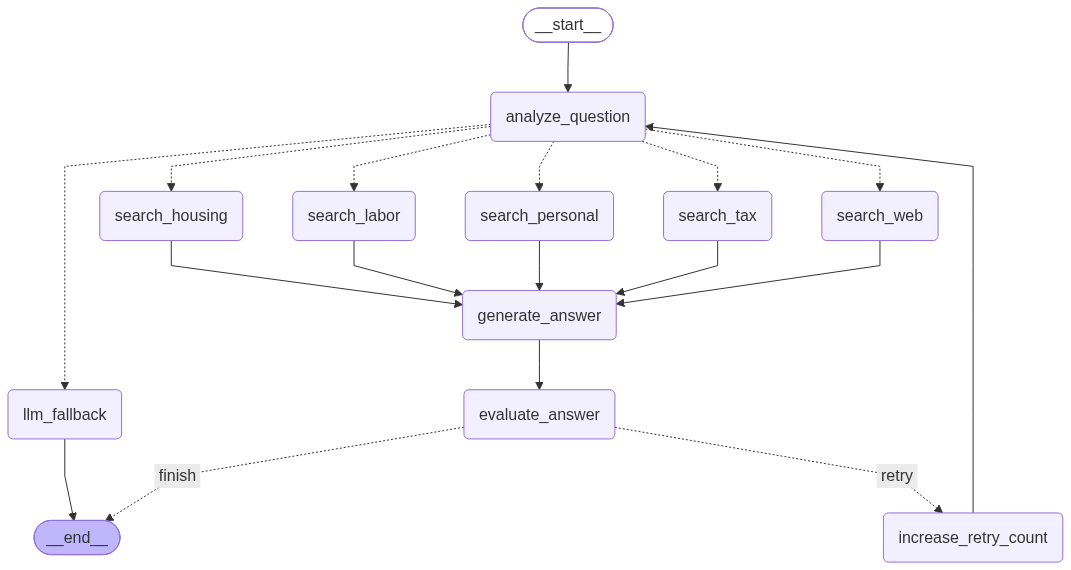

In [44]:
display(Image(legal_rag_agent.get_graph().draw_mermaid_png()))

## 35. CLI 실행 함수


In [45]:
def run_cli() -> None:
    print("생활법률 LangGraph RAG Agent")
    print("종료하려면 q 또는 quit 입력\n")

    while True:
        question = input("질문: ").strip()

        if question.lower() in {"q", "quit", "exit"}:
            break

        result = legal_rag_agent.invoke({"question": question, "retry_count": 0})
        
        print("\n[최종 답변]")
        print(result.get("final_answer", "답변 없음"))
        print("\n[평가]")
        print(json.dumps(result.get("evaluation_report", {}), ensure_ascii=False, indent=2))
        print("-" * 80)

## 36. Gradio 실행 함수


In [46]:
def run_gradio() -> None:
    import gradio as gr

    graph = build_legal_rag_agent(with_hitl=True)

    def chat(message: str, history):
        config = {"configurable": {"thread_id": str(uuid.uuid4())}}
        result = graph.invoke({"question": message, "retry_count": 0}, config=config)
        report = result.get("evaluation_report", {})
        return (
            f"{result.get('final_answer', '답변 없음')}\n\n"
            f"---\n평가 점수: {report.get('total_score', 'N/A')}/60\n"
            f"{report.get('brief_evaluation', '')}"
        )

    demo = gr.ChatInterface(
        fn=chat,
        title="생활법률 AI 어시스턴트",
        description="개인정보보호법, 근로기준법, 주택임대차보호법 질문에 답변합니다.",
        examples=[
            "사업장에서 CCTV를 설치할 때 주의해야 할 법적 사항은 무엇인가요?",
            "연차휴가 부여 기준에 대해서 설명해주세요.",
            "전월세 계약 갱신 요구권의 행사 기간과 조건은 어떻게 되나요?",
        ],
    )
    demo.launch()

## 37. 실행


In [ ]:
# 노트북 테스트 실행
# 먼저 PRJ_06_01 노트북으로 chroma_db를 생성한 뒤 실행하세요.
question = "연차휴가 부여 기준에 대해서 설명해주세요."
result = legal_rag_agent.invoke({"question": question, "retry_count": 0})

print("[최종 답변]")
print(result.get("final_answer", "답변 없음"))

print("\n[평가 결과]")
print(json.dumps(result.get("evaluation_report", {}), ensure_ascii=False, indent=2))

# Gradio로 실행하려면 아래 주석을 해제하세요.
# run_gradio()

---근로기준법: 문서 검색---
---근로기준법: 정보 추출 및 평가---
---근로기준법: 쿼리 재작성---
---근로기준법: 문서 검색---
---근로기준법: 정보 추출 및 평가---
---근로기준법: 답변 생성---
---최종 답변 생성---
---Self-check 답변 평가---
---근로기준법: 문서 검색---
---근로기준법: 정보 추출 및 평가---
---근로기준법: 쿼리 재작성---
---근로기준법: 문서 검색---
---근로기준법: 정보 추출 및 평가---
---근로기준법: 답변 생성---
---최종 답변 생성---
---Self-check 답변 평가---
[최종 답변]
근로기준법에 따르면, 연차유급휴가는 근로자의 근로 기간에 따라 다르게 부여됩니다. 구체적인 기준은 다음과 같습니다.

1. **1년 미만 근로자**: 입사 후 1개월 개근 시 1일의 유급휴가가 주어지며, 최대 11일까지 받을 수 있습니다. 이는 근로기준법 제60조 제2항에 근거합니다.

2. **1년 이상 근로자**: 근로자가 1년간 80% 이상 출근한 경우, 15일의 유급휴가가 주어집니다. 이는 근로기준법 제60조 제1항에 명시되어 있습니다.

3. **근속 기간 3년 이상**: 3년 이상 근무한 근로자의 경우, 매 2년마다 1일의 유급휴가가 추가로 부여됩니다. 이는 근로기준법 제60조 제3항에 따라 이루어집니다.

또한, 사용자는 근로자가 청구한 시기에 연차휴가를 부여해야 하지만, 사업 운영에 막대한 지장이 있을 경우 해당 시기를 변경할 수 있습니다.

이러한 연차유급휴가는 근로자의 심신 회복과 재충전을 위한 법적 권리로서 보장됩니다.

[평가 결과]
{
  "scores": {
    "accuracy": 4,
    "relevance": 5,
    "completeness": 4,
    "citation_accuracy": 3,
    "clarity": 5,
    "objectivity": 5
  },
  "total_score": 26,
  "brief_e

In [ ]:
run_gradio()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---개인정보보호법: 문서 검색---
---개인정보보호법: 정보 추출 및 평가---
---개인정보보호법: 답변 생성---
---최종 답변 생성---
---Self-check 답변 평가---
---개인정보보호법: 문서 검색---
---개인정보보호법: 정보 추출 및 평가---
---개인정보보호법: 답변 생성---
---최종 답변 생성---
---Self-check 답변 평가---
